# Case Study 2  -COVID-19 Research Abstract Clustering with TF-IDF, PCA, and K-Means

### Import Libaries

In [2]:
import re
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from nltk.stem import PorterStemmer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

## 1. Load the Data

In [3]:
# Update this path if needed
DATA_PATH = Path("./metadata/metadata.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Head:")
display(df.head())

print("\nInfo:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

Head:


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,"Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, Jeddah, ...",10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with cult...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b02786f8929fd9c900897fb.json,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC35282/,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in lung disease?,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract are commonly associated with elevated production of nitric oxide (NO•...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cross, Carroll E",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737eb0a2f63f2dce2e5a7d.json,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC59543/,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,"Surfactant protein-D (SP-D) participates in the innate response to inhaled microorganisms and organic antigens, and ...",2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa72528f2eeaae1d58927.json,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC59549/,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide with diverse biological activity that has been implicated in numerous...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a376498df9bf41f7123605.json,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC59574/,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in response to pneumovirus infection,10.1186/rr61,PMC59580,11686888,no-cc,"Respiratory syncytial virus (RSV) and pneumonia virus of mice (PVM) are viruses of the family Paramyxoviridae, subfa...",2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Rosenberg, Helene F",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f56016f4981ae2ca6031b32.json,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC59580/,NaN



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056660 entries, 0 to 1056659
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   cord_uid          1056660 non-null  object 
 1   sha               373766 non-null   object 
 2   source_x          1056660 non-null  object 
 3   title             1056157 non-null  object 
 4   doi               656780 non-null   object 
 5   pmcid             389571 non-null   object 
 6   pubmed_id         498932 non-null   object 
 7   license           1056660 non-null  object 
 8   abstract          821116 non-null   object 
 9   publish_time      1054846 non-null  object 
 10  authors           1032791 non-null  object 
 11  journal           969338 non-null   object 
 12  mag_id            0 non-null        float64
 13  who_covidence_id  482935 non-null   object 
 14  arxiv_id          14249 non-null    object 
 15  pdf_json_files    373766 non-null   object

mag_id              1056660
arxiv_id            1042411
pmc_json_files       740918
sha                  682894
pdf_json_files       682894
pmcid                667089
who_covidence_id     573725
pubmed_id            557728
doi                  399880
url                  369726
abstract             235544
journal               87322
s2_id                 80192
authors               23869
publish_time           1814
title                   503
cord_uid                  0
source_x                  0
license                   0
dtype: int64

The dataset is downloaded from https://www.kaggle.com/datasets/allen-institute-for-ai/CORD-19-research-challenge . It contains metadata for COVID-19 and coronavirus-related research papers. Each row represents **one article/paper**, and the `abstract` field provides a concise summary of that paper. 
For this analysis, the `abstract` column is used because it captures the main purpose, methods, and findings of each article in a compact form.

## 2. Clean the Text (Abstract Only)

In [4]:
# Remove rows with missing abstracts
abstract_df = df.loc[df["abstract"].notna(), ["cord_uid", "title", "abstract", "publish_time", "journal"]].copy()

print(f"Rows before removing missing abstracts: {len(df):,}")
print(f"Rows after removing missing abstracts:  {len(abstract_df):,}")

Rows before removing missing abstracts: 1,056,660
Rows after removing missing abstracts:  821,116


In [5]:
#Convert text to lowercase
#Remove punctuation and numbers
def clean_text_fast(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]+", " ", text)
    tokens = text.split()
    return " ".join(
        stemmer.stem(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    )


In [6]:
#Apply stemming
#Remove stop words
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

In [8]:
# first drop missing
abstract_df = abstract_df.loc[abstract_df["abstract"].notna()].copy()


In [9]:
# apply once
abstract_df["cleaned_abstract"] = abstract_df["abstract"].map(clean_text_fast)

# remove empty rows after cleaning
abstract_df = abstract_df.loc[abstract_df["cleaned_abstract"].str.len() > 0].copy()

In [12]:
display(abstract_df[["title", "abstract", "cleaned_abstract"]].head())
print(f"Usable abstracts after cleaning: {len(abstract_df):,}")

,title,abstract,cleaned_abstract
0,"Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, Jeddah, ...",OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with cult...,object retrospect chart review describ epidemiolog clinic featur patient cultur proven mycoplasma pneumonia infect k...
1,Nitric oxide: a pro-inflammatory mediator in lung disease?,Inflammatory diseases of the respiratory tract are commonly associated with elevated production of nitric oxide (NO•...,inflammatori diseas respiratori tract commonli associ elev product nitric oxid increas indic depend oxid stress know...
2,Surfactant protein-D and pulmonary host defense,"Surfactant protein-D (SP-D) participates in the innate response to inhaled microorganisms and organic antigens, and ...",surfact protein particip innat respons inhal microorgan organ antigen contribut immun inflammatori regul lung synthe...
3,Role of endothelin-1 in lung disease,Endothelin-1 (ET-1) is a 21 amino acid peptide with diverse biological activity that has been implicated in numerous...,endothelin amino acid peptid divers biolog activ implic numer diseas potent mitogen regul smooth muscl tone inflamma...
4,Gene expression in epithelial cells in response to pneumovirus infection,"Respiratory syncytial virus (RSV) and pneumonia virus of mice (PVM) are viruses of the family Paramyxoviridae, subfa...",respiratori syncyti viru rsv pneumonia viru mice pvm virus famili paramyxovirida subfamili pneumoviru caus clinic im...


Usable abstracts after cleaning: 820,737


## 3. Text Vectorization (TF-IDF)

In [10]:
MAX_FEATURES = 2000
#Convert the cleaned abstract text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85
)

X_tfidf = vectorizer.fit_transform(abstract_df["cleaned_abstract"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (820737, 2000)


## 4. Dimensionality Reduction (PCA)

In [13]:
MAX_DOCS_FOR_PCA = 5000
RANDOM_STATE = 42

if X_tfidf.shape[0] > MAX_DOCS_FOR_PCA:
    sampled_idx = abstract_df.sample(MAX_DOCS_FOR_PCA, random_state=RANDOM_STATE).index
    analysis_df = abstract_df.loc[sampled_idx].copy()
else:
    analysis_df = abstract_df.copy()

analysis_df = analysis_df.reset_index(drop=True)

X_sample_tfidf = vectorizer.transform(analysis_df["cleaned_abstract"])
X_dense = X_sample_tfidf.toarray()

print("Analysis subset shape for PCA:", X_dense.shape)

Analysis subset shape for PCA: (5000, 2000)


In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_dense)

print("PCA output shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA output shape: (5000, 2)
Explained variance ratio: [0.01717726 0.01331036]
Total explained variance: 0.030487618311222986


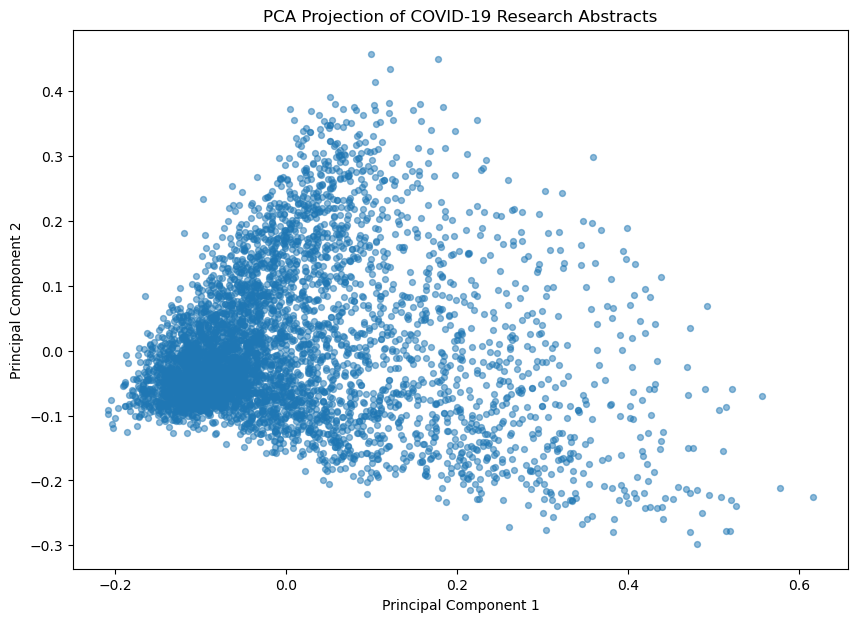

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=18)
plt.title("PCA Projection of COVID-19 Research Abstracts")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 5. Clustering (K-Means)

In [18]:
candidate_k = range(3, 8)
scores = []

for k in candidate_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append((k, score))

score_df = pd.DataFrame(scores, columns=["k", "silhouette_score"])
display(score_df)

best_k = int(score_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print(f"Selected k based on the highest silhouette score: {best_k}")

,k,silhouette_score
0,3,0.521039
1,4,0.438152
2,5,0.416764
3,6,0.427589
4,7,0.409327


Selected k based on the highest silhouette score: 3


The notebook selects the value of `k` with the highest silhouette score among the tested options.  
This gives a simple data-driven choice by balancing *cluster separation* and *cluster cohesion*.

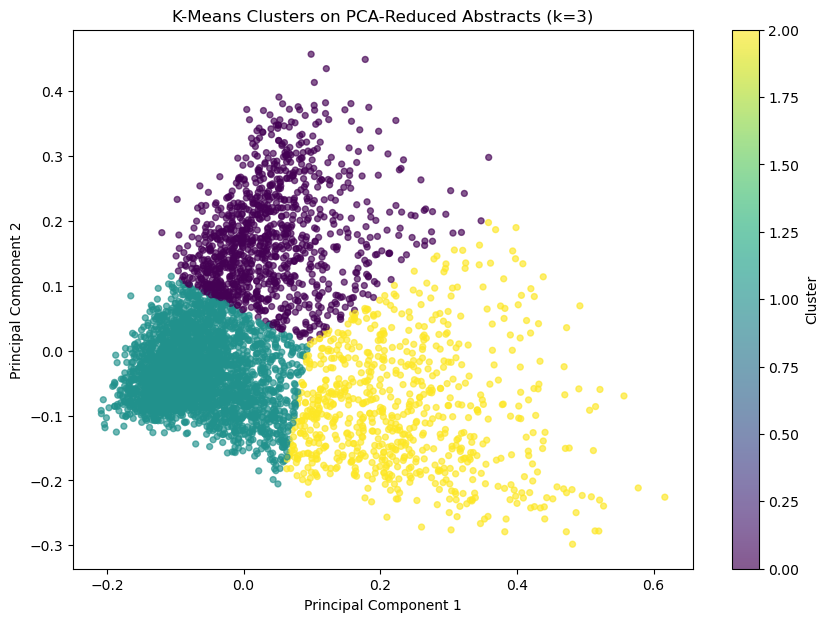

In [19]:
k = best_k

kmeans = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
analysis_df["cluster"] = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=analysis_df["cluster"],
    alpha=0.65,
    s=18
)
plt.title(f"K-Means Clusters on PCA-Reduced Abstracts (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 6. Interpretation

In [20]:
cluster_sizes = analysis_df["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
display(cluster_sizes)

,cluster,count
0,0,1065
1,1,3184
2,2,751


In [21]:
feature_names = np.array(vectorizer.get_feature_names_out())
sample_tfidf_df = pd.DataFrame(X_sample_tfidf.toarray(), columns=feature_names)
sample_tfidf_df["cluster"] = analysis_df["cluster"]

top_terms_per_cluster = {}

for cluster_id in sorted(analysis_df["cluster"].unique()):
    cluster_mean = sample_tfidf_df.loc[sample_tfidf_df["cluster"] == cluster_id, feature_names].mean(axis=0)
    top_terms = cluster_mean.sort_values(ascending=False).head(12).index.tolist()
    top_terms_per_cluster[cluster_id] = top_terms

top_terms_df = pd.DataFrame({
    "cluster": list(top_terms_per_cluster.keys()),
    "top_terms": [", ".join(v) for v in top_terms_per_cluster.values()]
})

display(top_terms_df)

,cluster,top_terms
0,0,"patient, covid, hospit, diseas, sever, clinic, infect, case, treatment, studi, care, group"
1,1,"cluster, covid, use, health, pandem, studi, model, effect, data, social, result, student"
2,2,"cluster, cov, sar, sar cov, infect, vaccin, cell, covid, antibodi, protein, coronaviru, viru"


In [22]:
for cluster_id in sorted(analysis_df["cluster"].unique()):
    print("=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("Top terms:", ", ".join(top_terms_per_cluster[cluster_id]))
    print("\nSample titles:")
    sample_titles = analysis_df.loc[analysis_df["cluster"] == cluster_id, "title"].dropna().head(5).tolist()
    for i, title in enumerate(sample_titles, start=1):
        print(f"{i}. {title}")
    print()

CLUSTER 0
Top terms: patient, covid, hospit, diseas, sever, clinic, infect, case, treatment, studi, care, group

Sample titles:
1. [Clinical observation on 103 patients of severe acute respiratory syndrome treated by integrative traditional Chinese and Western Medicine].
2. Shoulder Injury Related to Vaccine Administration and a Growing Challenge: A Focused Review.
3. Effects of the Lower Airway Secretions on Airway Opening Pressures and Suction Pressures in Critically Ill COVID-19 Patients: A Computational Simulation
4. Reinforced Biologic Mesh Reduces Postoperative Complications Compared to Biologic Mesh after Ventral Hernia Repair.
5. Gender-Associated Difference following COVID-19 virus infection: Implications for Thymosin alpha-1 Therapy

CLUSTER 1
Top terms: cluster, covid, use, health, pandem, studi, model, effect, data, social, result, student

Sample titles:
1. The Sturm und Drang of the CDC’s Home Eviction Moratorium (preprint)
2. Antimicrobial photodynamic inactivation in na

In [23]:
# Simple cluster summary table
summary_rows = []
for cluster_id in sorted(analysis_df["cluster"].unique()):
    cluster_subset = analysis_df.loc[analysis_df["cluster"] == cluster_id]
    summary_rows.append({
        "cluster": cluster_id,
        "count": len(cluster_subset),
        "share_of_subset": round(len(cluster_subset) / len(analysis_df), 3),
        "top_terms": ", ".join(top_terms_per_cluster[cluster_id][:8])
    })

cluster_summary = pd.DataFrame(summary_rows)
display(cluster_summary)

,cluster,count,share_of_subset,top_terms
0,0,1065,0.213,"patient, covid, hospit, diseas, sever, clinic, infect, case"
1,1,3184,0.637,"cluster, covid, use, health, pandem, studi, model, effect"
2,2,751,0.150,"cluster, cov, sar, sar cov, infect, vaccin, cell, covid"


The K-Means clusters represent groups of COVID-19 research abstracts with similar topics based on their text content. Cluster 0 mainly focuses on clinical and patient-related studies, including hospital cases, disease severity, treatment, and clinical care. Cluster 1 appears to focus on public health, social impact, and research analysis, such as pandemic studies, models, and health or social outcomes. Cluster 2 mainly represents biological and laboratory research, including vaccines, antibodies, proteins, and virus mechanisms. The clusters show moderate separation because each cluster highlights different themes (clinical care, public health research, and molecular/biological studies), but some overlap exists since all abstracts are related to COVID-19 research.

## 7. Reflection

##### How well TF-IDF, PCA, and K-Means worked for this task

TF-IDF, PCA, and K-Means worked reasonably well for identifying general themes in the COVID-19 research abstracts. TF-IDF converted the text into numerical features that highlight important terms in each abstract. PCA reduced the high-dimensional TF-IDF data into two components, which made it easier to visualize the structure of the data. K-Means then grouped the abstracts into clusters, and the results showed meaningful themes such as clinical studies, public health research, and biological or vaccine-related studies.

##### What could be improved

Some clusters still overlap because TF-IDF only captures word frequency and not deeper meaning. Using more advanced text representations such as word embeddings (Word2Vec, BERT) could improve topic separation. In addition, experimenting with different numbers of clusters or using topic modeling methods like LDA could produce clearer and more interpretable research themes.